# CS decomposition: De La O & Myers (JF 2021), Tables III-VII

**Paper:** De La O, Ricardo, and Sean Myers, 2021, "Subjective Cash Flow and Discount Rate Expectations," *Journal of Finance* 76(3). (`delao_myers.pdf` in this folder.)

**What this notebook computes**, each table for the datasets below through the identical code path:

- **Table III** — correlations of price ratios with expected one-year cash-flow growth, realized future one-year growth, and forecast errors;
- **Table IV** — one-year variance decomposition $CF_1$/$DR_1$/$LT$ (paper eqs. (8)-(9));
- **Table V** — extended decomposition: two-year cash flow news $CF_2$ and 10-year discount rate news $DR_{10}$ (eqs. (10)-(11));
- **Table VI** — full-horizon $CF$/$DR$ for the price-dividend ratio via the decay model (eqs. (12)-(16));
- **Table VII** — full-horizon $CF$/$DR$ for the price-earnings ratio via the decay model (eqs. (17)-(19)).

| Label | Expectations | Realized growth & price ratios |
|---|---|---|
| **DLM posted data** | DLM (I/B/E/S aggregation) | DLM (Compustat aggregation via index divisor) |
| **Reconstructed** | ours | Shiller-based (our reconstruction) |
| **DLM E\*, Shiller data** | DLM | Shiller-based (our reconstruction) |

The third dataset is the apples-to-apples benchmark for the reconstruction: comparing **Reconstructed** against **DLM E\*, Shiller data** isolates the expectations difference with the realized data and price ratios held fixed. (DLM and Shiller realized dividends diverge materially in GFC quarters — e.g., one-year realized dividend growth from 2008Q4 is $-9\%$ in DLM's data vs $-24\%$ in Shiller's — so comparisons that mix the two data bases confound expectations quality with data-source differences.)

**Data availability caveat for Tables V-VII:** DLM's *posted* files contain only one-year expectations, so $CF_2$ and the growth-side rows of Tables VI/VII can be computed **only for the reconstructed series** (whose files carry two-year columns). The return-based statistics ($DR_{10}$, the Table VI/VII returns rows) use the Graham-Harvey survey. The "DLM E\*, Shiller data" hybrid appears only in Tables III/IV: in Tables V-VII its rows would exactly duplicate the Reconstructed rows (the only statistics it can produce there are returns-based, which depend solely on the shared survey and the price ratio it shares with the reconstruction), so it is excluded from those tables.

The DLM-posted-data columns replicate the published tables; validation against the published values is documented in the notes at the bottom.

**Sample range:** all windows that ended 2015Q3 in the paper are controlled by `SAMPLE_END` in the config cell; the default extends them to **2022Q1**, the end of DLM's posted expectations (the binding series — the reconstruction runs to 2024Q4 and the GH survey to 2024Q1). Set `SAMPLE_END = '2015Q3'` to reproduce the paper's samples, on which the validation in the notes section was performed. Statistics needing realized growth truncate automatically at each dataset's realized end (DLM 2021Q3, reconstructed 2023Q4 — so within a common window the DLM rows can have a couple fewer quarters in Table III).

**How to swap in a new reconstruction:** edit the file paths in the `DATASETS` dict in the config cell — every downstream cell loops over the loaded datasets.

In [1]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize_scalar

pd.set_option('display.width', 160)

# Data files live in data/, extrapolated outputs in output/.
# Adjust here if running from a different working directory.
DATA_DIR   = Path('data')
OUTPUT_DIR = Path('output')

# File pairs. Edit paths here to swap in a different reconstruction --
# every downstream cell loops over the loaded datasets.
DATASETS = {
    'DLM posted data': {
        'dividends': DATA_DIR / 'Dividend_growth_expectations.xlsx',
        'earnings':  DATA_DIR / 'Earnings_growth_expectations.xlsx',
    },
    'Reconstructed': {
        'dividends': DATA_DIR / 'Dividend_growth_expectations_reconstructed.xlsx',
        'earnings':  DATA_DIR / 'Earnings_growth_expectations_reconstructed.xlsx',
    },
}
RETURNS_FILE = DATA_DIR / 'return_expectations_quarterly.xlsx'

EARNINGS_BLOCK = 'current earnings'  # which denominator block of the earnings file (paper headline)
RETURN_MEASURE = 'sp_1yr_mean'       # Graham-Harvey 1-yr mean; paper Table II reports its std = 1.3%
RETURN_MEASURE_10Y = 'sp_10yr_mean'  # Graham-Harvey 10-yr mean (annualized), for Tables V and VI
NW_LAGS = 4                          # Newey-West lags (quarterly data, overlapping 1-yr forecasts)

# Sample windows. The paper's: 2003Q1-2015Q3 / 1976Q1-2002Q4 / 1976Q1-2015Q3 / 1985Q1-2015Q3.
# SAMPLE_END extends every window that ended 2015Q3. Default = 2022Q1, the end of DLM's posted
# expectations (reconstructed files run to 2024Q4, GH returns to 2024Q1, so DLM is the binding
# series). Set SAMPLE_END = '2015Q3' to reproduce the paper's samples. Realized-growth columns
# auto-truncate where each dataset's realized data end (DLM 2021Q3, reconstructed 2023Q4).
# ── Full-extrapolation mode ────────────────────────────────────────────────
# When True, the headline decomposition runs on the full 1920+ extrapolated
# sample (Section 8b). The OOD support is known to be weak pre-2000, but the
# point of the exercise is to use the full extrapolation; OOD quarters are
# NOT excluded. The paper-replication tables (III-VII) above keep their
# original windows for validation.
FULL_EXTRAP = True
FULL_EXTRAP_START = '1920Q1'

SAMPLE_END = '2022Q1'
PD_SAMPLE = ('2003Q1', SAMPLE_END)
PE_SAMPLES = [('2003Q1', SAMPLE_END), ('1976Q1', '2002Q4'), ('1976Q1', SAMPLE_END)]
PE2_SAMPLE = ('1985Q1', SAMPLE_END)  # two-year earnings expectations start in 1985
SAMPLE_LABEL = f'{PD_SAMPLE[0]}-{PD_SAMPLE[1]}'

EXPORT_PDF = True  # write LaTeX comparison tables and compile with pdflatex at the end

## 1. Data loading

The dividend files have a single header row; the earnings files have a two-row header (block titles, then column names) with three blocks differing by the denominator of the price ratio and of expected growth: current earnings $e_t$, dividends $d_t$, and CAPE earnings $e^{ca}_t$. The paper's Tables III/IV use the **current-earnings block** — verified: it reproduces Table III Panel B (2003-2015) correlations 0.93 / 0.61 / 0.07 essentially exactly, while the other two blocks do not come close.

Loaders select columns **by name** within the chosen block, so the original files and the reconstructed files load through the same code path. Two-year expectation columns (`Expected two-year log dividend/earnings growth`, **cumulative** two-year log growth) are loaded when present and set to NaN otherwise — they exist only in the reconstructed files and feed Tables V and VI.

In [2]:
def _qidx(s):
    """'2003Q1' -> integer quarter index for sample masks."""
    y, q = s.split('Q')
    return int(y) * 4 + int(q) - 1


def load_dividends(path):
    df = pd.read_excel(path)
    out = pd.DataFrame({
        'year': pd.to_numeric(df['Year']),
        'quarter': pd.to_numeric(df['Quarter']),
        'exp_dg': pd.to_numeric(df['Expected one-year log dividend growth']),
        'real_dg': pd.to_numeric(df['Realized next year log dividend growth']),
        'pd': pd.to_numeric(df['Current log price-dividend ratio']),
    })
    two = 'Expected two-year log dividend growth'   # cumulative; reconstructed files only
    out['exp_dg2'] = pd.to_numeric(df[two]) if two in df.columns else np.nan
    out['qi'] = out.year.astype(int) * 4 + out.quarter.astype(int) - 1
    return out


def load_earnings(path, block_key=EARNINGS_BLOCK):
    raw = pd.read_excel(path, header=None)
    titles = raw.iloc[0]
    block_starts = [c for c in raw.columns if pd.notna(titles[c]) and 'Denominator' in str(titles[c])]
    starts = [c for c in block_starts if block_key in str(titles[c])]
    assert len(starts) == 1, f"block '{block_key}' not found uniquely in {path}"
    c0 = starts[0]
    later = [c for c in block_starts if c > c0]
    c1 = later[0] if later else raw.shape[1]

    names = raw.iloc[1]
    def col(name, required=True):
        hits = [c for c in range(c0, c1) if str(names[c]).strip() == name]
        if not hits:
            assert not required, f"column '{name}' not found in block at {path}"
            return pd.Series(np.nan, index=raw.index[2:])
        return pd.to_numeric(raw.iloc[2:][hits[0]], errors='coerce')

    out = pd.DataFrame({
        'year': pd.to_numeric(raw.iloc[2:][0]),
        'quarter': pd.to_numeric(raw.iloc[2:][1]),
        'exp_eg': col('Expected one-year log earnings growth'),
        'real_eg': col('Realized next year log earnings growth'),
        'pe': col('Current price ratio'),
        'exp_eg2': col('Expected two-year log earnings growth', required=False),
    }).reset_index(drop=True)
    out['qi'] = out.year.astype(int) * 4 + out.quarter.astype(int) - 1
    return out


def load_returns(path, measure=RETURN_MEASURE, measure10=RETURN_MEASURE_10Y):
    df = pd.read_excel(path)
    out = pd.DataFrame({
        'year': df['year'], 'quarter': df['qtr'],
        # surveys report percent simple returns; convert to log gross returns
        'exp_r': np.log(1 + df[measure] / 100),
        'exp_r10': np.log(1 + df[measure10] / 100),   # annualized 10-yr expectation
    })
    out['qi'] = out.year.astype(int) * 4 + out.quarter.astype(int) - 1
    return out


returns = load_returns(RETURNS_FILE)
data = {}
for label, files in DATASETS.items():
    if files['dividends'].exists() and files['earnings'].exists():
        data[label] = {'div': load_dividends(files['dividends']),
                       'earn': load_earnings(files['earnings'])}
        print(f"{label}: dividends {len(data[label]['div'])} rows "
              f"({data[label]['div'].year.min():.0f}Q{data[label]['div'].quarter.iloc[0]:.0f}+), "
              f"earnings {len(data[label]['earn'])} rows")
    else:
        print(f"{label}: files not found, skipping")
print(f"returns: {len(returns)} rows, measures = {RETURN_MEASURE}, {RETURN_MEASURE_10Y}")

DLM posted data: dividends 77 rows (2003Q1+), earnings 185 rows
Reconstructed: dividends 91 rows (2002Q2+), earnings 196 rows
returns: 96 rows, measures = sp_1yr_mean, sp_10yr_mean


### Third dataset: DLM expectations on Shiller realized data and price ratios

DLM's expectations paired with the reconstruction's (Shiller-based) realized growth and price ratios. This is the benchmark the **Reconstructed** rows should be read against: both are evaluated on identical realized data, so any difference between the two is purely the expectations series.

In [3]:
if 'DLM posted data' in data and 'Reconstructed' in data:
    sh_div = (data['DLM posted data']['div'][['qi', 'year', 'quarter', 'exp_dg', 'exp_dg2']]
              .merge(data['Reconstructed']['div'][['qi', 'real_dg', 'pd']], on='qi'))
    sh_earn = (data['DLM posted data']['earn'][['qi', 'year', 'quarter', 'exp_eg', 'exp_eg2']]
               .merge(data['Reconstructed']['earn'][['qi', 'real_eg', 'pe']], on='qi'))
    data['DLM E*, Shiller data'] = {'div': sh_div, 'earn': sh_earn}
    print(f"DLM E*, Shiller data: dividends {len(sh_div)} rows, earnings {len(sh_earn)} rows")

DLM E*, Shiller data: dividends 77 rows, earnings 185 rows


### Fourth dataset: Extrapolated E* (from macro_expectations_pipeline)

The synthetic survey-consistent expectations produced by
`macro_expectations_pipeline.ipynb` and saved under `output/{series}/`. These
extend back to 1920 but here are paired with the Reconstructed (Shiller-based)
realized growth and price ratios, so within the survey-overlap window they are
directly comparable to the **DLM E\*, Shiller data** benchmark above: any
difference is purely the expectations series. The pre-2003 extrapolated values
have no matching realized/price data in the survey file and are dropped by the
merge, so the decomposition tables use only the overlap window.

The extrapolated expectations are monthly; we collapse each to the
quarter-end month to match the quarterly wave structure.


In [ ]:
# ── Load extrapolated expectations and build the "Extrapolated E*" dataset ─────
EXTRAP_DIR = OUTPUT_DIR

def _load_extrap_q(series_name):
    """Monthly extrapolated CSV -> quarterly (quarter-end month) with qi index."""
    p = EXTRAP_DIR / series_name / 'extrapolated_expectations.csv'
    df = pd.read_csv(p)
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    q = (df.groupby(['year', 'quarter'])
           .agg(predicted=('predicted', 'last'), ood=('ood', 'last'))
           .reset_index())
    q['qi'] = q.year.astype(int) * 4 + q.quarter.astype(int) - 1
    return q

if 'Reconstructed' in data:
    # Extrapolated expectations (the exp_* columns)
    ex_dg  = _load_extrap_q('dividend_growth').rename(columns={'predicted': 'exp_dg'})
    ex_dg2 = _load_extrap_q('dividend_growth_2yr').rename(columns={'predicted': 'exp_dg2'})
    ex_eg  = _load_extrap_q('earnings_growth').rename(columns={'predicted': 'exp_eg'})
    ex_eg2 = _load_extrap_q('earnings_growth_2yr').rename(columns={'predicted': 'exp_eg2'})

    # Realized growth and price ratios from the Reconstructed dataset (Shiller-based)
    rec_div  = data['Reconstructed']['div'][['qi', 'year', 'quarter', 'real_dg', 'pd']]
    rec_earn = data['Reconstructed']['earn'][['qi', 'real_eg', 'pe']]

    extrap_div = (ex_dg[['qi', 'year', 'quarter', 'exp_dg']]
                  .merge(ex_dg2[['qi', 'exp_dg2']], on='qi')
                  .merge(rec_div[['qi', 'real_dg', 'pd']], on='qi'))
    extrap_earn = (ex_eg[['qi', 'exp_eg']]
                   .merge(ex_eg2[['qi', 'exp_eg2']], on='qi')
                   .merge(rec_earn[['qi', 'real_eg', 'pe']], on='qi')
                   .merge(ex_eg[['qi', 'year', 'quarter']], on='qi'))

    data['Extrapolated E*'] = {'div': extrap_div, 'earn': extrap_earn}
    print(f"Extrapolated E*: dividends {len(extrap_div)} rows "
          f"({extrap_div.year.min():.0f}Q{extrap_div.quarter.iloc[0]:.0f}+), "
          f"earnings {len(extrap_earn)} rows")
    print(f"  exp_dg range  [{extrap_div.exp_dg.min():.3f}, {extrap_div.exp_dg.max():.3f}]")
    print(f"  exp_eg range  [{extrap_earn.exp_eg.min():.3f}, {extrap_earn.exp_eg.max():.3f}]")
else:
    print("Reconstructed dataset not loaded — cannot build Extrapolated E* "
          "(needs its realized growth and price ratios).")


### Fifth dataset: Extrapolated E* (full history, 1920+)

This is the **main extended result**. The extrapolated expectations are paired
with Shiller-based realized growth and price ratios computed directly from
`ie_data.xls` back to 1920 — so the full-horizon decomposition can run on the
entire extrapolated sample, not just the post-2003 survey-overlap window.

Conventions (matched to the reconstructed survey file): quarter = quarter-end
month (Q1=Mar, Q2=Jun, Q3=Sep, Q4=Dec); price ratios are log P/D and log P/E;
realized growth is forward log growth over the next 4 quarters (1yr) or 8
quarters (2yr). Returns expectations come from the extrapolated returns series.

Reliability of the pre-survey period varies by series (the dividend and return
series are heavily out-of-distribution before ~2000) — see the caveat section
near the end. This dataset shows the headline full-sample numbers; the caveat
section re-runs with OOD months flagged.


In [ ]:
# ── Build full-history Shiller realized growth + price ratios (1920+) ──────────
def _shiller_quarterly(path=DATA_DIR / 'ie_data.xls'):
    raw = pd.read_excel(path, sheet_name='Data', header=7)
    raw.columns = raw.columns.str.strip()
    raw = raw.dropna(subset=['Date'])
    def _pf(f):
        y = int(f); m = round((f - y) * 100)
        return pd.Timestamp(year=y, month=max(1, min(12, m if m > 0 else 1)), day=1)
    raw['date'] = raw['Date'].apply(_pf)
    raw = raw.set_index('date').sort_index()
    P = pd.to_numeric(raw['P'], errors='coerce')
    Dv = pd.to_numeric(raw['D'], errors='coerce')
    Ev = pd.to_numeric(raw['E'], errors='coerce')
    qend = P.index[P.index.month.isin([3, 6, 9, 12])]
    q = pd.DataFrame(index=qend)
    q['P'], q['D'], q['E'] = P.reindex(qend), Dv.reindex(qend), Ev.reindex(qend)
    q['year'] = q.index.year
    q['quarter'] = (q.index.month / 3).astype(int)
    q['qi'] = q.year * 4 + q.quarter - 1
    q['pd'] = np.log(q['P'] / q['D'])
    q['pe'] = np.log(q['P'] / q['E'])
    q['real_dg']  = np.log(q['D'].shift(-4) / q['D'])    # 1yr forward log growth
    q['real_eg']  = np.log(q['E'].shift(-4) / q['E'])
    q['real_dg2'] = np.log(q['D'].shift(-8) / q['D'])    # 2yr cumulative forward
    q['real_eg2'] = np.log(q['E'].shift(-8) / q['E'])
    return q[q.year >= 1920].reset_index(drop=True)

_shq = _shiller_quarterly()

# Extrapolated returns -> exp_r, exp_r10 (log gross), full history
def _extrap_returns_q():
    r1  = _load_extrap_q('returns_1yr').rename(columns={'predicted': 'r1'})
    r10 = _load_extrap_q('returns_10yr').rename(columns={'predicted': 'r10'})
    m = r1[['qi', 'r1']].merge(r10[['qi', 'r10']], on='qi')
    # extrapolated returns are in percent; convert to log gross
    m['exp_r']   = np.log(1 + m['r1'] / 100)
    m['exp_r10'] = np.log(1 + m['r10'] / 100)
    return m[['qi', 'exp_r', 'exp_r10']]

returns_full = _extrap_returns_q()

# Assemble full-history Extrapolated dataset
_ex_dg  = _load_extrap_q('dividend_growth').rename(columns={'predicted': 'exp_dg'})
_ex_dg2 = _load_extrap_q('dividend_growth_2yr').rename(columns={'predicted': 'exp_dg2'})
_ex_eg  = _load_extrap_q('earnings_growth').rename(columns={'predicted': 'exp_eg'})
_ex_eg2 = _load_extrap_q('earnings_growth_2yr').rename(columns={'predicted': 'exp_eg2'})

# attach OOD flags (max across the cash-flow series that feed each ratio)
_ood_dg  = _load_extrap_q('dividend_growth')[['qi', 'ood']].rename(columns={'ood': 'ood_dg'})
_ood_eg  = _load_extrap_q('earnings_growth')[['qi', 'ood']].rename(columns={'ood': 'ood_eg'})
_ood_r   = _load_extrap_q('returns_1yr')[['qi', 'ood']].rename(columns={'ood': 'ood_r'})

full_div = (_shq[['qi', 'year', 'quarter', 'pd', 'real_dg', 'real_dg2']]
            .merge(_ex_dg[['qi', 'exp_dg']], on='qi')
            .merge(_ex_dg2[['qi', 'exp_dg2']], on='qi')
            .merge(_ood_dg, on='qi').merge(_ood_r, on='qi'))
full_earn = (_shq[['qi', 'year', 'quarter', 'pe', 'real_eg', 'real_eg2']]
             .merge(_ex_eg[['qi', 'exp_eg']], on='qi')
             .merge(_ex_eg2[['qi', 'exp_eg2']], on='qi')
             .merge(_ood_eg, on='qi').merge(_ood_r, on='qi'))

data['Extrapolated E* (full)'] = {'div': full_div, 'earn': full_earn}
returns_full_ds = returns_full   # used by the extended-sample table cells below

print(f"Extrapolated E* (full): dividends {len(full_div)} rows "
      f"({full_div.year.min():.0f}Q{full_div.quarter.iloc[0]:.0f} - "
      f"{full_div.year.max():.0f}Q{full_div.quarter.iloc[-1]:.0f}), "
      f"earnings {len(full_earn)} rows")
print(f"  pre-2003 quarters: {len(full_div[full_div.year < 2003])}  "
      f"(OOD share div: {full_div[full_div.year<2003].ood_dg.mean():.0%}, "
      f"earn: {full_earn[full_earn.year<2003].ood_eg.mean():.0%})")


### Series comparison: DLM posted data vs reconstructed

The four ingredients of each table, DLM's series against the reconstruction. Shaded band = the configured short sample (`PD_SAMPLE`). The realized-growth panels (b) make the Shiller-vs-Compustat divergence in GFC quarters directly visible.

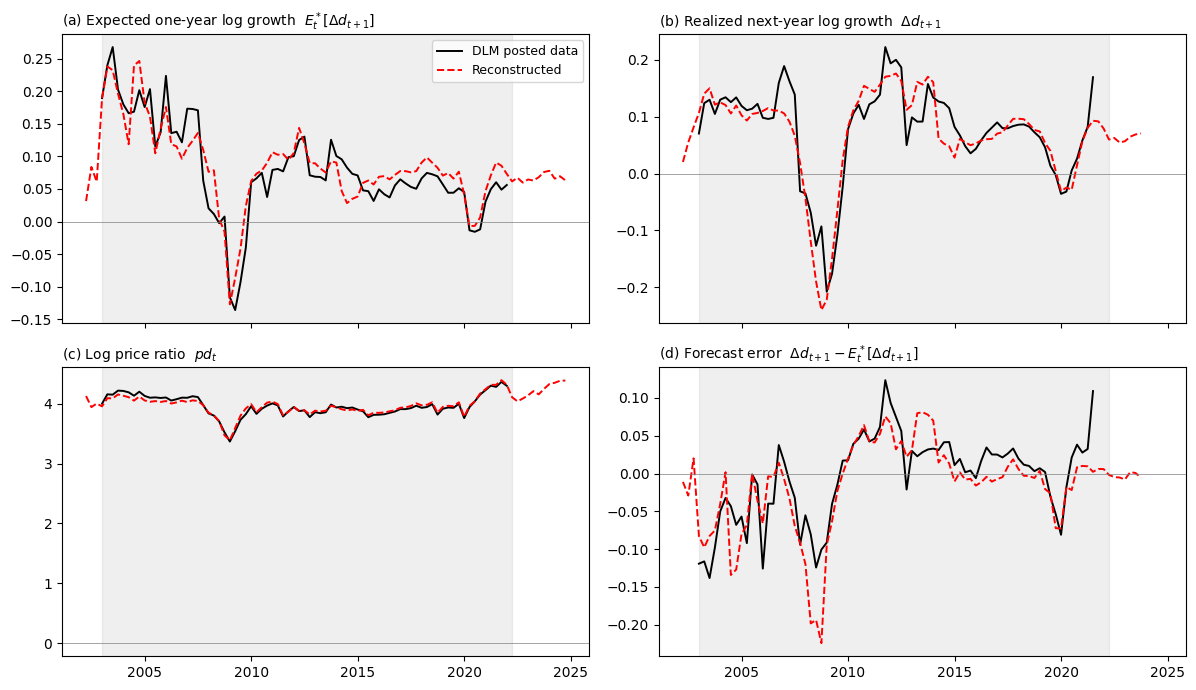

In [4]:
import matplotlib.pyplot as plt


def _tq(s):
    y, q = s.split('Q')
    return int(y) + (int(q) - 1) / 4


def plot_series_comparison(kind):
    exp, real, ratio, g, p = {
        'div':  ('exp_dg', 'real_dg', 'pd', r'\Delta d_{t+1}', 'pd_t'),
        'earn': ('exp_eg', 'real_eg', 'pe', r'\Delta e_{t+1}', 'pe_t'),
    }[kind]
    panels = [(exp,   f'(a) Expected one-year log growth  $E_t^*[{g}]$'),
              (real,  f'(b) Realized next-year log growth  ${g}$'),
              (ratio, f'(c) Log price ratio  ${p}$'),
              ('fe',  f'(d) Forecast error  ${g} - E_t^*[{g}]$')]
    styles = {'DLM posted data': dict(color='k', ls='-'),
              'Reconstructed':   dict(color='r', ls='--')}

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    for src, st in styles.items():
        d = data[src][kind].copy()
        d['t'] = d.year + (d.quarter - 1) / 4
        d['fe'] = d[real] - d[exp]
        for ax, (c, _) in zip(axes.flat, panels):
            ax.plot(d.t, d[c], lw=1.4, label=src, **st)
    lo, hi = _tq(PD_SAMPLE[0]), _tq(PD_SAMPLE[1]) + 0.25
    for ax, (_, title) in zip(axes.flat, panels):
        ax.axvspan(lo, hi, color='grey', alpha=0.12)
        ax.axhline(0, color='grey', lw=0.5)
        ax.set_title(title, fontsize=10, loc='left')
    axes[0, 0].legend(fontsize=9)
    fig.tight_layout()
    plt.show()


plot_series_comparison('div')

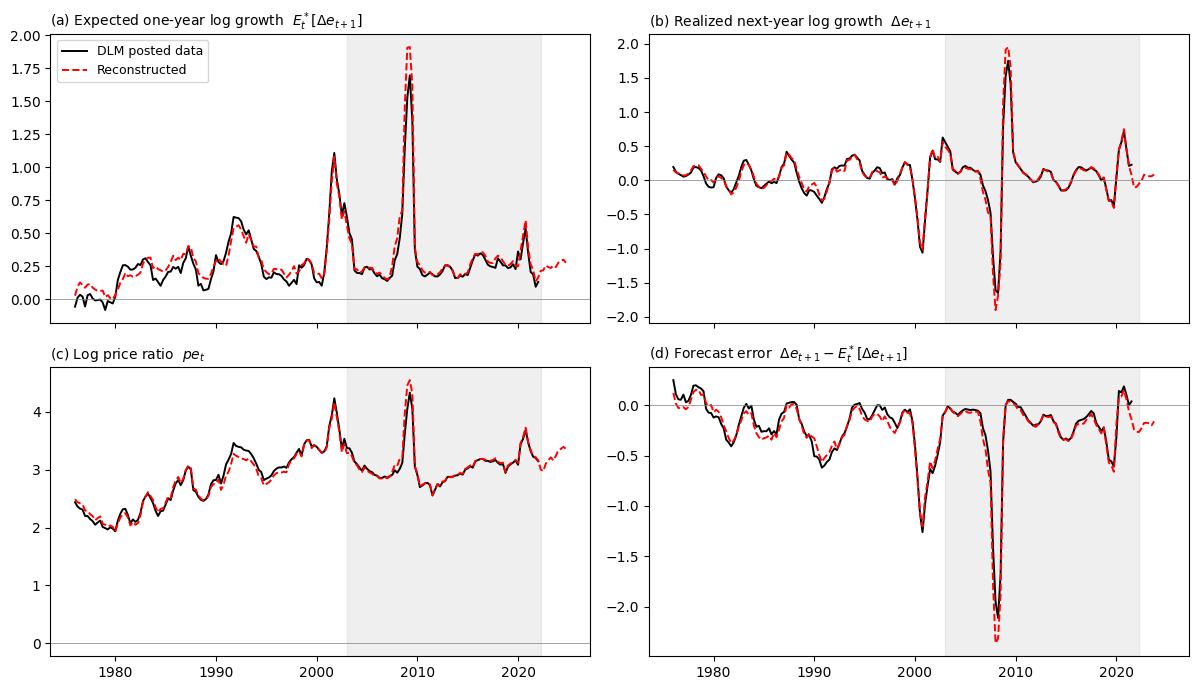

In [5]:
plot_series_comparison('earn')

## 2. Econometrics: small-sample-adjusted Newey-West standard errors

The paper reports "small-sample adjusted Newey-West standard errors" without further detail. We use:

- **Regression coefficients (Tables IV-VI):** OLS slope with Newey-West (Bartlett kernel, `NW_LAGS = 4`) HAC variance and a $T/(T-k)$ degrees-of-freedom adjustment. With quarterly observations of overlapping one-year-ahead forecasts, errors are serially correlated by construction (MA(3) at least), so 4 lags is the natural choice.
- **Correlations (Table III):** the correlation is computed as the OLS slope of the standardized variables, with the same Newey-West machinery applied to that regression.

Both choices were calibrated against the published tables: with $L=4$ they reproduce the paper's reported standard errors closely (e.g., Table IV $pd$ row: ours 0.035 / 0.013 / 0.040 vs. published 0.034 / 0.013 / 0.037). A GMM delta-method standard error for the correlation gives materially *smaller* values than the paper, so the standardized-regression convention is what matches their reported magnitudes.

In [6]:
def nw_lrvar(u, L):
    """Newey-West (Bartlett) long-run variance of moment series u (T x k)."""
    u = u - u.mean(axis=0)
    T = len(u)
    S = u.T @ u / T
    for l in range(1, L + 1):
        G = u[l:].T @ u[:-l] / T
        S += (1 - l / (L + 1)) * (G + G.T)
    return S


def ols_nw(y, x, L=NW_LAGS):
    """Slope and small-sample-adjusted Newey-West SE from OLS of y on [1, x]."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.solve(X.T @ X, X.T @ y)
    e = y - X @ b
    T, k = X.shape
    S = nw_lrvar(X * e[:, None], L)
    Q = X.T @ X / T
    V = np.linalg.solve(Q, np.linalg.solve(Q, S).T).T / T * T / (T - k)
    return b[1], np.sqrt(V[1, 1])


def corr_nw(x, y, L=NW_LAGS):
    """Pearson correlation with NW SE, computed as the standardized-OLS slope."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    xs = (x - x.mean()) / x.std(ddof=1)
    ys = (y - y.mean()) / y.std(ddof=1)
    return ols_nw(ys, xs, L)

## 3. Table III — correlations of price ratios with expected/realized growth

For each sample, three correlations with the current price ratio: expected one-year growth, realized future one-year growth, and the forecast error $fe_{t+1} = \text{realized} - \text{expected}$.

Alongside the paper's Pearson correlations, the table reports **Spearman (rank) versions** — Pearson on within-sample ranks, same Newey-West machinery applied to the ranked series. Motivation: the Pearson forecast-error correlation over 2003-2015 is dominated by a handful of GFC quarters (2008 alone contributes >150% of the covariance, with $pd$ and $fe$ both far below their means); the rank correlation is leverage-robust and shows the sign of the typical-quarter relationship (negative, as in the long samples).

In [7]:
def _corr_row(df, pcol, expcol, realcol, lo, hi, L=NW_LAGS):
    m = (df.qi >= _qidx(lo)) & (df.qi <= _qidx(hi))
    d = df.loc[m, [pcol, expcol, realcol]].dropna()
    fe = d[realcol] - d[expcol]
    rp = d[pcol].rank()
    return {
        'N': len(d),
        'Expected': corr_nw(d[pcol], d[expcol], L),
        'Realized': corr_nw(d[pcol], d[realcol], L),
        'Forecast error': corr_nw(d[pcol], fe, L),
        'Expected (rank)': corr_nw(rp, d[expcol].rank(), L),
        'Realized (rank)': corr_nw(rp, d[realcol].rank(), L),
        'FE (rank)': corr_nw(rp, fe.rank(), L),
    }


def compute_table3(div, earn, L=NW_LAGS):
    """Rows of Table III keyed (ratio, sample) -> {'N', 'Expected', 'Realized', 'Forecast error'}."""
    out = {}
    lo, hi = PD_SAMPLE
    out[('pd', f'{lo}-{hi}')] = _corr_row(div, 'pd', 'exp_dg', 'real_dg', lo, hi, L)
    for lo, hi in PE_SAMPLES:
        out[('pe', f'{lo}-{hi}')] = _corr_row(earn, 'pe', 'exp_eg', 'real_eg', lo, hi, L)
    return out

## 4. Table IV — one-year variance decomposition

From the log-linearized identity (paper eq. (1)), $pd_t = \kappa + \Delta d_{t+1} - r_{t+1} + \rho\, pd_{t+1}$ with $\rho = e^{\overline{pd}}/(1 + e^{\overline{pd}})$, the one-year decomposition (eq. (8)) is

$$1 = \underbrace{\frac{\mathrm{cov}(E_t^*[\Delta d_{t+1}],\ pd_t)}{\mathrm{var}(pd_t)}}_{CF_1} + \underbrace{\frac{-\mathrm{cov}(E_t^*[r_{t+1}],\ pd_t)}{\mathrm{var}(pd_t)}}_{DR_1} + \underbrace{\rho\,\frac{\mathrm{cov}(E_t^*[pd_{t+1}],\ pd_t)}{\mathrm{var}(pd_t)}}_{LT},$$

and analogously for $pe_t$ (eq. (9), an approximation because payout-ratio news of order $1-\rho$ is dropped). Each component is the slope from an individual OLS regression on the current price ratio. Construction of the unobserved pieces, following Section IV.A of the paper:

- $E_t^*[r_{t+1}] = \log(1 + \text{GH 1-yr mean}/100)$ — Graham-Harvey CFO survey;
- $E_t^*[pd_{t+1}] = (pd_t - \kappa - E_t^*[\Delta d_{t+1}] + E_t^*[r_{t+1}])/\rho$, inferred from the identity ($\kappa$ drops out of all covariances, so it is set to 0). This makes $CF_1 + DR_1 + LT = 1$ **mechanically** for the $pd$ decomposition;
- $E_t^*[pe_{t+1}] = E_t^*[pd_{t+1}] + de_t + E_t^*[\Delta d_{t+1}] - E_t^*[\Delta e_{t+1}]$ where $de_t = pe_t - pd_t$ is the log payout ratio — i.e., the expected future $pe$ is inferred from the expected future $pd$ and expected growth in the payout ratio. For the $pe$ decomposition the sum is then $\approx 1$ but not exact (the paper reports 0.997).

The 1976-2015 row uses only the earnings file (no dividend expectations or return survey exist that far back), so only $CF_1$ is estimated — as in the paper.

In [8]:
def compute_table4(div, earn, ret, L=NW_LAGS):
    out = {}

    # --- pd and pe decompositions, short sample with return expectations ---
    lo, hi = PD_SAMPLE
    s = (div.merge(earn[['qi', 'exp_eg', 'pe']], on='qi')
            .merge(ret[['qi', 'exp_r']], on='qi'))
    s = s[(s.qi >= _qidx(lo)) & (s.qi <= _qidx(hi))]
    s = s.dropna(subset=['exp_dg', 'exp_eg', 'exp_r', 'pd', 'pe']).copy()

    pd_bar = s['pd'].mean()
    rho = np.exp(pd_bar) / (1 + np.exp(pd_bar))
    s['E_pd1'] = (s['pd'] - s.exp_dg + s.exp_r) / rho                      # E*[pd_{t+1}], kappa = 0
    s['E_pe1'] = s.E_pd1 + (s.pe - s['pd']) + s.exp_dg - s.exp_eg          # E*[pe_{t+1}]

    key = ('pd', f'{lo}-{hi}')
    out[key] = {'N': len(s), 'rho': rho,
                'CF1': ols_nw(s.exp_dg, s['pd'], L),
                'DR1': ols_nw(-s.exp_r, s['pd'], L),
                'LT':  ols_nw(rho * s.E_pd1, s['pd'], L)}
    key = ('pe', f'{lo}-{hi}')
    out[key] = {'N': len(s), 'rho': rho,
                'CF1': ols_nw(s.exp_eg, s.pe, L),
                'DR1': ols_nw(-s.exp_r, s.pe, L),
                'LT':  ols_nw(rho * s.E_pe1, s.pe, L)}

    # --- long earnings sample: CF1 only ---
    lo, hi = PE_SAMPLES[-1]
    le = earn[(earn.qi >= _qidx(lo)) & (earn.qi <= _qidx(hi))].dropna(subset=['exp_eg', 'pe'])
    out[('pe', f'{lo}-{hi}')] = {'N': len(le), 'CF1': ols_nw(le.exp_eg, le.pe, L)}
    return out

## 5. Results: Tables III and IV

Each block of rows is one row of the original table, computed for each dataset by the identical code. Read **Reconstructed** against **DLM E\*, Shiller data** (same realized data and price ratios; the difference is purely the expectations series). **DLM posted data** is the replication baseline.

In [9]:
def _fmt(est, se, dp):
    return f"{est:.{dp}f} ({se:.{dp}f})"


def comparison_display(results_by_source, columns, row_label, dp, row_order=None):
    """Stack per-source rows under each table row; blank cells where a stat is unavailable."""
    rows = []
    keys = list(row_order) if row_order else []
    for res in results_by_source.values():
        keys += [k for k in res if k not in keys]
    for key in keys:
        for src, res in results_by_source.items():
            r = res.get(key)
            if r is None or not any(c in r for c in columns):
                continue
            rows.append({'Row': row_label(key), 'Source': src,
                         **{c: _fmt(*r[c], dp) if c in r else '' for c in columns}})
    return pd.DataFrame(rows).set_index(['Row', 'Source'])


T3_PANEL = {'pd': 'A: Corr(pd_t, .)', 'pe': 'B: Corr(pe_t, .)'}
T_RATIO = {'pd': 'Price-dividend ratio', 'pe': 'Price-earnings ratio'}

t3 = {src: compute_table3(d['div'], d['earn']) for src, d in data.items()}
t4 = {src: compute_table4(d['div'], d['earn'], returns) for src, d in data.items()}

table3_df = comparison_display(t3, ['Expected', 'Realized', 'Forecast error',
                                    'Expected (rank)', 'Realized (rank)', 'FE (rank)'],
                               lambda k: f"{T3_PANEL[k[0]]}  {k[1]}", dp=2)
table4_df = comparison_display(t4, ['CF1', 'DR1', 'LT'],
                               lambda k: f"{T_RATIO[k[0]]}  {k[1]}", dp=3)

print("TABLE III - Correlation of Cash Flow Growth and Price Ratios")
display(table3_df)

TABLE III - Correlation of Cash Flow Growth and Price Ratios


Expected     Realized Forecast error Expected (rank) Realized (rank)     FE (rank)
Row                             Source                                                                                                     
A: Corr(pd_t, .)  2003Q1-2022Q1 DLM posted data       0.68 (0.19)  0.63 (0.19)    0.01 (0.25)     0.59 (0.20)     0.51 (0.15)  -0.08 (0.22)
                                Reconstructed         0.53 (0.24)  0.55 (0.28)    0.21 (0.23)     0.52 (0.20)     0.31 (0.19)  -0.03 (0.21)
                                DLM E*, Shiller data  0.47 (0.24)  0.55 (0.28)    0.19 (0.23)     0.45 (0.22)     0.31 (0.19)  -0.11 (0.22)
B: Corr(pe_t, .)  2003Q1-2022Q1 DLM posted data       0.85 (0.21)  0.62 (0.14)    0.16 (0.09)     0.72 (0.10)     0.49 (0.14)   0.25 (0.16)
                                Reconstructed         0.89 (0.17)  0.60 (0.13)    0.08 (0.07)     0.73 (0.12)     0.38 (0.14)   0.12 (0.16)
                                DLM E*, Shiller data  0.89 (0.16)  0.60 (0.13)    0.20 (0.08)     0.68 (0.13)     0.38 (0.14)   0.18 (0.16)
B: Corr(pe_t, .)  1976Q1-2002Q4 DLM posted data       0.74 (0.17)  0.14 (0.16)   -0.48 (0.16)     0.66 (0.14)     0.28 (0.15)  -0.41 (0.17)
                                Reconstructed         0.76 (0.18)  0.12 (0.18)   -0.48 (0.17)     0.70 (0.13)     0.24 (0.17)  -0.43 (0.17)
                                DLM E*, Shiller data  0.71 (0.19)  0.12 (0.18)   -0.48 (0.17)     0.61 (0.16)     0.24 (0.17)  -0.42 (0.18)
B: Corr(pe_t, .)  1976Q1-2022Q1 DLM posted data       0.73 (0.17)  0.30 (0.16)   -0.21 (0.11)     0.65 (0.11)     0.36 (0.11)  -0.18 (0.15)
                                Reconstructed         0.74 (0.20)  0.32 (0.19)   -0.19 (0.11)     0.66 (0.10)     0.28 (0.12)  -0.21 (0.15)
                                DLM E*, Shiller data  0.74 (0.18)  0.32 (0.19)   -0.16 (0.14)     0.60 (0.12)     0.28 (0.12)  -0.20 (0.15)

In [10]:
print("TABLE IV - Variance Decomposition of Price Ratios Using One-Year Estimates")
for src, res in t4.items():
    print(f"  {src}: rho = {res[('pd', SAMPLE_LABEL)]['rho']:.4f}")
display(table4_df)

TABLE IV - Variance Decomposition of Price Ratios Using One-Year Estimates
  DLM posted data: rho = 0.9813
  Reconstructed: rho = 0.9813
  DLM E*, Shiller data: rho = 0.9813


CF1             DR1             LT
Row                                 Source                                                            
Price-dividend ratio  2003Q1-2022Q1 DLM posted data       0.258 (0.093)  -0.047 (0.014)  0.789 (0.092)
                                    Reconstructed         0.212 (0.096)  -0.048 (0.016)  0.836 (0.095)
                                    DLM E*, Shiller data  0.217 (0.112)  -0.048 (0.016)  0.831 (0.109)
Price-earnings ratio  2003Q1-2022Q1 DLM posted data       0.775 (0.200)  -0.002 (0.005)  0.223 (0.202)
                                    Reconstructed         0.857 (0.163)   0.001 (0.005)  0.139 (0.164)
                                    DLM E*, Shiller data  0.709 (0.130)   0.001 (0.005)  0.285 (0.132)
Price-earnings ratio  1976Q1-2022Q1 DLM posted data       0.382 (0.088)                               
                                    Reconstructed         0.416 (0.114)                               
                                    DLM E*, Shiller data  0.395 (0.093)

## 6. Table V — extended decomposition: $CF_2$ and $DR_{10}$

Paper eqs. (10)-(11): $CF_2$ and $DR_{10}$ are slopes from individual regressions of $\sum_{j=1}^{2}\rho^{j-1}E_t^*[\Delta d_{t+j}]$ and $-\sum_{j=1}^{10}\rho^{j-1}E_t^*[r_{t+j}]$ on the current price ratio (earnings analog for $pe_t$). Construction:

- The files' two-year expectation columns are **cumulative**, $G_2 = E_t^*[\Delta d_{t+1} + \Delta d_{t+2}]$, so the year-2 term is $E_t^*[\Delta d_{t+2}] = G_2 - G_1$ and the regressor is $G_1 + \rho\,(G_2 - G_1)$.
- The Graham-Harvey 10-year forecast is an **annualized average**, so the cumulative 10-year log expectation is $10\,r^{(10)}$ and the years-2-10 total is $E_t^*[r_{t+2,t+10}] = 10\,r^{(10)} - E_t^*[r_{t+1}]$ (the construction the paper itself uses in eq. (15)). We allocate it **flat** across years 2-10 inside the $\rho^{j-1}$ weighting; with $\rho \approx 0.98$ the within-horizon allocation is nearly irrelevant for the regression coefficient.

Samples: the $pd$ and $pe$ rows use the short window (`PD_SAMPLE`); the third row ($pe$, $CF_2$ only) starts 1985Q1, when two-year earnings expectations begin. Two-year expectations exist only in the reconstructed files, so $CF_2$ is blank for DLM posted data; $DR_{10}$ (survey-based) is computed for both. The "DLM E\*, Shiller data" hybrid is excluded — its rows would duplicate the Reconstructed ones exactly (see the header note).

In [11]:
def compute_table5(div, earn, ret, L=NW_LAGS):
    out = {}
    lo, hi = PD_SAMPLE
    s = (div.merge(earn[['qi', 'exp_eg', 'exp_eg2', 'pe']], on='qi')
            .merge(ret[['qi', 'exp_r', 'exp_r10']], on='qi'))
    s = s[(s.qi >= _qidx(lo)) & (s.qi <= _qidx(hi))]
    s = s.dropna(subset=['pd', 'pe', 'exp_r', 'exp_r10']).copy()

    pd_bar = s['pd'].mean()
    rho = np.exp(pd_bar) / (1 + np.exp(pd_bar))
    w9 = sum(rho ** k for k in range(1, 10))                 # rho^1 + ... + rho^9
    disc10 = s.exp_r + w9 * (10 * s.exp_r10 - s.exp_r) / 9   # sum_{j=1}^{10} rho^{j-1} E*[r_{t+j}]

    for ratio, expcol, exp2col in [('pd', 'exp_dg', 'exp_dg2'), ('pe', 'exp_eg', 'exp_eg2')]:
        row = {'N': len(s), 'rho': rho,
               'DR10': ols_nw(-disc10, s[ratio], L)}
        d2 = s.dropna(subset=[expcol, exp2col])
        if len(d2) >= 12:
            disc2 = d2[expcol] + rho * (d2[exp2col] - d2[expcol])
            row['CF2'] = ols_nw(disc2, d2[ratio], L)
        out[(ratio, f'{lo}-{hi}')] = row

    # --- long earnings sample: CF2 only (rho carried from the short window) ---
    lo2, hi2 = PE2_SAMPLE
    le = earn[(earn.qi >= _qidx(lo2)) & (earn.qi <= _qidx(hi2))].dropna(subset=['exp_eg', 'exp_eg2', 'pe'])
    if len(le) >= 12:
        disc2 = le.exp_eg + rho * (le.exp_eg2 - le.exp_eg)
        out[('pe', f'{lo2}-{hi2}')] = {'N': len(le), 'CF2': ols_nw(disc2, le.pe, L)}
    return out


# hybrid excluded: its rows would exactly duplicate Reconstructed (returns-only stats, shared survey + ratio)
t5 = {src: compute_table5(d['div'], d['earn'], returns) for src, d in data.items()
      if src != 'DLM E*, Shiller data'}
table5_df = comparison_display(t5, ['CF2', 'DR10'],
                               lambda k: f"{T_RATIO[k[0]]}  {k[1]}", dp=3)

print("TABLE V - Extended Variance Decomposition of Price Ratios")
display(table5_df)

TABLE V - Extended Variance Decomposition of Price Ratios


CF2            DR10
Row                                 Source                                        
Price-dividend ratio  2003Q1-2022Q1 DLM posted data                 -0.387 (0.252)
                                    Reconstructed    0.302 (0.149)  -0.457 (0.306)
Price-earnings ratio  2003Q1-2022Q1 DLM posted data                 -0.168 (0.089)
                                    Reconstructed    0.923 (0.173)  -0.135 (0.076)
Price-earnings ratio  1985Q1-2022Q1 Reconstructed    0.640 (0.171)

## 7. Table VI — full-horizon decomposition of the price-dividend ratio

Paper eqs. (12)-(16): long-horizon expectations follow a simple decay back to their means, $E_t^*[\Delta d_{t+1+j}] - \mu_d = \phi_d^j\,(E_t^*[\Delta d_{t+1}] - \mu_d)$ and likewise for returns with $\phi_r$, giving full-horizon news $CF = CF_1/(1-\rho\phi_d)$ and $DR = DR_1/(1-\rho\phi_r)$. Three estimations, all on the short window (`PD_SAMPLE`):

1. **Dividend growth:** $\phi_d$ from the regression $E_t^*[\Delta d_{t+2}] = a + \phi_d\,E_t^*[\Delta d_{t+1}] + \nu_t$ (eq. (14); NW standard errors); $CF = CF_1/(1-\rho\phi_d)$, $DR = 1 - CF$.
2. **Returns:** the slope $b$ of $E_t^*[r_{t+2,t+10}] = a + b\,E_t^*[r_{t+1}] + \nu_t$ identifies $\phi_r$ through $b = \sum_{k=1}^{9}\phi_r^k$ (eq. (15)); $\phi_r$ by numerical inversion, its SE by the delta method; $DR = DR_1/(1-\rho\phi_r)$, $CF = 1 - DR$.
3. **Joint:** $\phi_d$ and $\phi_r$ estimated by Gaussian ML on the two regressions **constrained by the identity** $1 = CF_1/(1-\rho\phi_d) + DR_1/(1-\rho\phi_r)$ (eq. (16)); implemented as a profile likelihood over $\phi_r$ with $\phi_d$ implied by the constraint, intercepts concentrated out, and the $\phi_r$ SE from the observed information of the profile.

As in the paper's table notes, the SEs for $CF$ and $DR$ combine the SEs of $CF_1$/$DR_1$ and $\phi_d$/$\phi_r$ by the delta method assuming independence. Rows 1 and 3 need two-year dividend expectations, so they exist only for the reconstructed dataset; row 2 is computed for DLM posted data and Reconstructed (its $\phi_r$ is survey-only, but $DR_1$ — and hence $DR$ — depends on the dataset's $pd$). The "DLM E\*, Shiller data" hybrid is excluded — its only producible row (Returns) would duplicate the Reconstructed one exactly.

The machinery is written once (`full_horizon_decomp`) and reused for Table VII, which is the identical estimation on the price-earnings ratio.

### The full-horizon model and the two estimators of $\phi_r$

**Setup.** Campbell–Shiller links the log price–dividend ratio to expected future
cash-flow growth and returns. Iterating the loglinear identity forward and taking
subjective (survey/extrapolated) expectations $E^*_t$ gives

$$
pd_t \;=\; \text{const} \;+\; \underbrace{E^*_t\!\sum_{j=1}^{\infty}\rho^{\,j-1}\,\Delta d_{t+j}}_{\text{cash-flow term } (CF)} \;-\; \underbrace{E^*_t\!\sum_{j=1}^{\infty}\rho^{\,j-1}\,r_{t+j}}_{\text{discount-rate term } (DR)},
$$

with $\rho = e^{\overline{pd}}/(1+e^{\overline{pd}})$. The decomposition asks what share
of the variation in $pd_t$ is accounted for by $CF$ versus $DR$ (and analogously
$pe_t$ for earnings). DLM identify each infinite sum from a one-period expectation
plus a **persistence parameter** that propagates it forward.

**One-period loadings.** Regressing the one-period expectations on the price ratio,

$$
CF_1 = \frac{\mathrm{Cov}(E^*_t\Delta d_{t+1},\,pd_t)}{\mathrm{Var}(pd_t)},
\qquad
DR_1 = \frac{\mathrm{Cov}(-E^*_t r_{t+1},\,pd_t)}{\mathrm{Var}(pd_t)} .
$$

**Growth persistence $\phi_g$.** Expected growth is assumed AR(1) under $E^*$, so the
second-year expectation scales the first: $\;E^*_t\Delta d_{t+2} = \phi_g\,E^*_t\Delta d_{t+1}$.
We estimate $\phi_g$ by regressing the implied year-2 expectation
$(\text{exp\_dg2}-\text{exp\_dg})$ on $\text{exp\_dg}$. The full-horizon cash-flow share is then the
geometric sum
$$
CF \;=\; \frac{CF_1}{1-\rho\,\phi_g}.
$$

**Return persistence $\phi_r$ — the object with two estimators.** Likewise expected
returns are AR(1), $E^*_t r_{t+j}=\phi_r^{\,j-1}E^*_t r_{t+1}$, giving
$DR = DR_1/(1-\rho\,\phi_r)$. The question is how to estimate $\phi_r$.

- **(A) DLM cross-horizon estimator (default).** DLM do not observe the expected-return
  *path*; they observe a 1-year and a 10-year expectation per date. Under AR(1),
  the cumulative 2-to-10-year expected return is
  $$
  E^*_t\!\big[r_{t+2,t+10}\big] \;=\; b\cdot E^*_t r_{t+1},
  \qquad
  b \;=\; \sum_{k=1}^{9}\phi_r^{\,k} \;\equiv\; h(\phi_r).
  $$
  We regress $\big(10\,\text{exp\_r10}-\text{exp\_r}\big)$ on $\text{exp\_r}$ to get $\hat b$, then invert
  $h(\phi_r)=\hat b$ for $\phi_r\in(0,1)$. Because $h$ is increasing and bounded —
  $h(0^+)\!\to\!0$, $h(1^-)\!\to\!9$ — a root exists **only if** $\hat b\in(0,9)$.

- **(B) AR(1) fallback (used when $\hat b\notin(0,9)$).** On the full 1920+
  extrapolation the cross-horizon slope is $\hat b\approx 15$, i.e. *no* admissible
  $\phi_r$ exists. This is not an outlier artifact (Huber/Theil–Sen also give
  $\hat b\approx15$); it reflects that the 1-year and 10-year return series were
  extrapolated by **independent models**, so their joint term structure is not
  forced to be AR(1)-consistent. Rather than saturate $\phi_r$ at the boundary, we
  estimate $\phi_r$ **directly as the first-order autocorrelation of the
  expected-return series**,
  $$
  E^*_t r_{t+1} \;=\; c + \phi_r\,E^*_{t-1} r_{t} + u_t,
  $$
  which is the literal meaning of the persistence parameter, is bounded in $(0,1)$ by
  construction, and on the full sample gives $\phi_r\approx0.91$ (vs $0.86$ in the
  survey window) — a sensible, stable value.

**Selection rule.** The code uses **(A)** whenever $\hat b\in(0,9)$ — so the survey-window
results remain exactly DLM-comparable — and falls back to **(B)** only when the
cross-horizon mapping has no admissible root. The estimator actually used is
recorded per row (`_phi_r_method`). In the joint CF+DR ML row, the return moment
relies on the same cross-horizon mapping; when that mapping is invalid we hold
$\phi_r$ at the AR(1) value and estimate only $\phi_g$.

**Caveat to flag in the paper.** Estimator (B) changes the identifying assumption
relative to DLM: it reads $\phi_r$ off the time-series persistence of expected
returns rather than off the 1yr-vs-10yr cross-horizon restriction. It is the more
robust choice for the extrapolated full sample, but it is a deliberate
methodological deviation and should be reported as such.


In [ ]:
def full_horizon_decomp(s, growth_exp, growth_exp2, ratio, phi_key, g_label, L=NW_LAGS):
    """Full-horizon CF/DR decomposition (paper eqs. (12)-(19)) for one price ratio.

    s: sample frame with columns [growth_exp, growth_exp2, ratio, 'pd', 'exp_r', 'exp_r10'].
    Three estimations: growth-survey only, return-survey only, joint ML under CF + DR = 1.
    """
    h  = lambda p: sum(p ** k for k in range(1, 10))          # b = phi(1-phi^9)/(1-phi)
    hp = lambda p: sum(k * p ** (k - 1) for k in range(1, 10))

    pd_bar = s['pd'].mean()
    rho = np.exp(pd_bar) / (1 + np.exp(pd_bar))
    CF1, seCF1 = ols_nw(s[growth_exp], s[ratio], L)
    DR1, seDR1 = ols_nw(-s.exp_r, s[ratio], L)

    out = {}
    have_2yr = s[growth_exp2].notna().sum() >= 12

    # --- row 1: growth expectations only ---
    if have_2yr:
        d = s.dropna(subset=[growth_exp2])
        y_g = d[growth_exp2] - d[growth_exp]                  # E*[growth in year 2]
        phi_g, se_phig = ols_nw(y_g, d[growth_exp], L)
        CF = CF1 / (1 - rho * phi_g)
        seCF = np.sqrt((1 / (1 - rho * phi_g)) ** 2 * seCF1 ** 2
                       + (CF1 * rho / (1 - rho * phi_g) ** 2) ** 2 * se_phig ** 2)
        out[g_label] = {phi_key: (phi_g, se_phig), 'CF': (CF, seCF), 'DR': (1 - CF, seCF)}

    # --- row 2: returns only ---
    # phi_r is the persistence of expected returns. Two estimators:
    #   (A) DLM cross-horizon: regress E*[r_{t+2,t+10}] on E*[r_{t+1}] to get
    #       slope b, then invert b = h(phi_r) = sum_{k=1..9} phi_r^k.
    #       h(.) is bounded in (0, 9), so b>=9 has no admissible root.
    #   (B) AR(1) fallback: estimate phi_r directly as the first-order
    #       autocorrelation of the expected-return series. Bounded by
    #       construction; used when (A) is unsolvable (b out of range).
    # Preference: use (A) where DLM-comparable; fall back to (B) otherwise.
    y_r = 10 * s.exp_r10 - s.exp_r                            # E*[r_{t+2,t+10}]
    b, se_b = ols_nw(y_r, s.exp_r, L)
    h_lo, h_hi = h(1e-6), h(0.999999)
    if h_lo < b < h_hi:
        phi_r_method = 'cross-horizon'
        phi_r = brentq(lambda p: h(p) - b, 1e-6, 0.999999)
        se_phir = se_b / hp(phi_r)
    else:
        phi_r_method = 'AR(1) fallback'
        # AR(1) coefficient of expected returns (ordered in time)
        er = s.sort_values('qi')['exp_r'].values
        er0, er1 = er[:-1], er[1:]
        phi_r, se_phir = ols_nw(pd.Series(er1), pd.Series(er0), L)
        phi_r = float(np.clip(phi_r, 1e-6, 0.999999))
        print(f'    [info] returns phi_r via AR(1) fallback (cross-horizon b={b:.2f} '
               f'outside (0, {h_hi:.1f})); phi_r={phi_r:.3f}.')
    DR = DR1 / (1 - rho * phi_r)
    seDR = np.sqrt((1 / (1 - rho * phi_r)) ** 2 * seDR1 ** 2
                   + (DR1 * rho / (1 - rho * phi_r) ** 2) ** 2 * se_phir ** 2)
    out['Returns'] = {'phi_r': (phi_r, se_phir), 'CF': (1 - DR, seDR),
                      'DR': (DR, seDR), '_phi_r_method': phi_r_method}

    # --- row 3: joint ML constrained by 1 = CF + DR ---
    # The return moment uses the cross-horizon mapping E*[r_{t+2,t+10}] = h(pr) E*[r_{t+1}].
    # When that mapping is admissible we estimate pr jointly; when it is not
    # (cross-horizon b out of range) the joint return moment is misspecified,
    # so we hold phi_r at the AR(1) fallback value and estimate only phi_g.
    if have_2yr:
        d = s.dropna(subset=[growth_exp2])
        xg, yg = d[growth_exp].values, (d[growth_exp2] - d[growth_exp]).values
        xr, yr = s.exp_r.values, y_r.values
        joint_ok = (h_lo < b < h_hi)

        def phi_g_of(pr):
            A = 1 - DR1 / (1 - rho * pr)                      # = CF1/(1 - rho*phi_g)
            return (1 - CF1 / A) / rho

        def negll(pr):
            eg = yg - phi_g_of(pr) * xg; eg = eg - eg.mean()
            er = yr - h(pr) * xr;        er = er - er.mean()
            return 0.5 * (len(eg) * np.log(eg @ eg / len(eg)) + len(er) * np.log(er @ er / len(er)))

        eps = 1e-4
        if joint_ok:
            pr3 = minimize_scalar(negll, bounds=(0.01, 0.95), method='bounded').x
            info = (negll(pr3 + eps) - 2 * negll(pr3) + negll(pr3 - eps)) / eps ** 2
            se_pr3 = 1 / np.sqrt(info) if info > 0 else np.nan
        else:
            # phi_r held at the AR(1) fallback value; the joint-ML curvature SE
            # is not defined, so carry the row-2 AR(1) SE for phi_r instead.
            pr3 = phi_r
            se_pr3 = se_phir
        pg3 = phi_g_of(pr3)
        DR3 = DR1 / (1 - rho * pr3)
        seDR3 = np.sqrt((1 / (1 - rho * pr3)) ** 2 * seDR1 ** 2
                        + (DR1 * rho / (1 - rho * pr3) ** 2) ** 2 * se_pr3 ** 2)
        # phi_g SE: delta method on the constraint mapping, independence across inputs
        g = lambda pr, c1, d1: (1 - c1 / (1 - d1 / (1 - rho * pr))) / rho
        d_pr = (g(pr3 + eps, CF1, DR1) - g(pr3 - eps, CF1, DR1)) / (2 * eps)
        d_c1 = (g(pr3, CF1 + eps, DR1) - g(pr3, CF1 - eps, DR1)) / (2 * eps)
        d_d1 = (g(pr3, CF1, DR1 + eps) - g(pr3, CF1, DR1 - eps)) / (2 * eps)
        se_pg3 = np.sqrt(d_pr ** 2 * se_pr3 ** 2 + d_c1 ** 2 * seCF1 ** 2 + d_d1 ** 2 * seDR1 ** 2)
        out[f'{g_label} and returns'] = {phi_key: (pg3, se_pg3), 'phi_r': (pr3, se_pr3),
                                         'CF': (1 - DR3, seDR3), 'DR': (DR3, seDR3)}
    return out


def compute_table6(div, ret, L=NW_LAGS):
    lo, hi = PD_SAMPLE
    s = div.merge(ret[['qi', 'exp_r', 'exp_r10']], on='qi')
    s = s[(s.qi >= _qidx(lo)) & (s.qi <= _qidx(hi))]
    s = s.dropna(subset=['exp_dg', 'pd', 'exp_r', 'exp_r10']).copy()
    return full_horizon_decomp(s, 'exp_dg', 'exp_dg2', 'pd', 'phi_d', 'Dividend growth', L)


t6 = {src: compute_table6(d['div'], returns) for src, d in data.items()
      if src != 'DLM E*, Shiller data'}
table6_df = comparison_display(t6, ['phi_d', 'phi_r', 'CF', 'DR'], lambda k: k, dp=2,
                               row_order=['Dividend growth', 'Returns', 'Dividend growth and returns'])

print(f"TABLE VI - Variance Decomposition of pd into Full-Horizon CF and DR ({SAMPLE_LABEL})")
display(table6_df)

## 8. Table VII — full-horizon decomposition of the price-earnings ratio

The identical estimation on the price-earnings ratio (paper eqs. (17)-(19)): $\phi_e$ from the regression of $E_t^*[\Delta e_{t+2}]$ on $E_t^*[\Delta e_{t+1}]$ (eq. (18)), the same $\phi_r$ equation (15), and full-horizon news $CF = CF_1/(1-\rho\phi_e)$, $DR = DR_1/(1-\rho\phi_r)$ with $CF_1$/$DR_1$ from the $pe$ regressions. The joint row imposes $1 = CF + DR$ (eq. (19), approximate for $pe$ because payout-ratio news is dropped). Sample = `PD_SAMPLE`; $\rho$ from the in-sample mean $pd$, as everywhere else. The paper's punchline here is the near-zero persistence of earnings growth expectations ($\phi_e = 0.06$ published) versus $\phi_d = 0.59$ for dividends — dividend smoothing in beliefs.

In [13]:
def compute_table7(div, earn, ret, L=NW_LAGS):
    lo, hi = PD_SAMPLE
    s = (div[['qi', 'pd']]
         .merge(earn[['qi', 'exp_eg', 'exp_eg2', 'pe']], on='qi')
         .merge(ret[['qi', 'exp_r', 'exp_r10']], on='qi'))
    s = s[(s.qi >= _qidx(lo)) & (s.qi <= _qidx(hi))]
    s = s.dropna(subset=['exp_eg', 'pe', 'pd', 'exp_r', 'exp_r10']).copy()
    return full_horizon_decomp(s, 'exp_eg', 'exp_eg2', 'pe', 'phi_e', 'Earnings growth', L)


t7 = {src: compute_table7(d['div'], d['earn'], returns) for src, d in data.items()
      if src != 'DLM E*, Shiller data'}
table7_df = comparison_display(t7, ['phi_e', 'phi_r', 'CF', 'DR'], lambda k: k, dp=2,
                               row_order=['Earnings growth', 'Returns', 'Earnings growth and returns'])

print(f"TABLE VII - Variance Decomposition of pe into Full-Horizon CF and DR ({SAMPLE_LABEL})")
display(table7_df)

TABLE VII - Variance Decomposition of pe into Full-Horizon CF and DR (2003Q1-2022Q1)


phi_e        phi_r           CF            DR
Row                         Source                                                              
Earnings growth             Reconstructed    0.08 (0.00)               0.93 (0.18)   0.07 (0.18)
Returns                     DLM posted data               0.44 (0.49)  1.00 (0.01)  -0.00 (0.01)
                            Reconstructed                 0.44 (0.49)  1.00 (0.01)   0.00 (0.01)
Earnings growth and returns Reconstructed    0.14 (0.17)  0.59 (0.24)  1.00 (0.01)   0.00 (0.01)

## 8b. FULL EXTRAPOLATION RESULTS (1920+) — headline

The complete decomposition run on the **Extrapolated E\* (full)** dataset over
the entire 1920-present sample, using Shiller-based realized growth / price
ratios and the **extrapolated return expectations** (`returns_full`). All
quarters are included — OOD support is known to be weak before ~2000, but the
purpose here is to use the full extrapolation, so OOD quarters are **not**
excluded.

Tables IV (one-year), V (CF2/DR10), VI (full-horizon pd) and VII (full-horizon
pe) are re-run on the full sample and compared to the survey-window (2003+)
numbers. The return-persistence root (phi_r) can be unsolvable on the full
sample when the implied long-horizon coefficient exceeds the admissible bound
(b > 9); those entries report NaN and the warning identifies them.


In [ ]:
# ── Run the full decomposition on the full 1920+ extrapolation ────────────────
# Temporarily widen the sample windows and swap in the extrapolated returns,
# then call the existing table functions on the full dataset.
EXT_LO = FULL_EXTRAP_START
EXT_HI = f'{int(_shq.year.max())}Q{int(_shq.quarter.iloc[-1])}'

_fd = data['Extrapolated E* (full)']['div']
_fe = data['Extrapolated E* (full)']['earn']
_rf = returns_full_ds          # extrapolated returns, full history (exp_r, exp_r10)

# Save originals, set full-sample windows
_orig = (PD_SAMPLE, PE_SAMPLES, PE2_SAMPLE, SAMPLE_LABEL)
PD_SAMPLE   = (EXT_LO, EXT_HI)
PE_SAMPLES  = [(EXT_LO, EXT_HI)]
PE2_SAMPLE  = (EXT_LO, EXT_HI)
SAMPLE_LABEL = f'{EXT_LO}-{EXT_HI}'

print(f"FULL EXTRAPOLATION DECOMPOSITION — sample {EXT_LO} to {EXT_HI}")
print(f"  {len(_fd)} quarters (vs 77 in the survey window)\n")

# Table III — correlations of price ratios with expected/realized growth
t3_full = {'Extrapolated E* (full)': compute_table3(_fd, _fe)}
t3_full_df = comparison_display(
    t3_full, ['Expected', 'Realized', 'Forecast error',
              'Expected (rank)', 'Realized (rank)', 'FE (rank)'],
    lambda k: f"{T3_PANEL[k[0]]}  {k[1]}", dp=2)
print("TABLE III (FULL) — correlations of cash-flow growth with price ratios")
display(t3_full_df)

# Table IV — one-year decomposition
t4_full = {'Extrapolated E* (full)': compute_table4(_fd, _fe, _rf)}
t4_full_df = comparison_display(
    t4_full, ['CF1', 'DR1', 'LT'],
    lambda k: f'{k[0]} ({k[1]})', dp=3)
print("TABLE IV (FULL) — one-year variance decomposition")
display(t4_full_df)

# Table V — extended CF2 / DR10
t5_full = {'Extrapolated E* (full)': compute_table5(_fd, _fe, _rf)}
t5_full_df = comparison_display(
    t5_full, ['CF2', 'DR10'],
    lambda k: f'{k[0]} ({k[1]})', dp=3)
print("\nTABLE V (FULL) — extended CF2 / DR10 decomposition")
display(t5_full_df)

# Table VI — full-horizon pd
t6_full = {'Extrapolated E* (full)': compute_table6(_fd, _rf)}
t6_full_df = comparison_display(
    t6_full, ['phi_d', 'phi_r', 'CF', 'DR'], lambda k: k, dp=2,
    row_order=['Dividend growth', 'Returns', 'Dividend growth and returns'])
print("\nTABLE VI (FULL) — full-horizon pd decomposition")
display(t6_full_df)

# Table VII — full-horizon pe
t7_full = {'Extrapolated E* (full)': compute_table7(_fd, _fe, _rf)}
t7_full_df = comparison_display(
    t7_full, ['phi_e', 'phi_r', 'CF', 'DR'], lambda k: k, dp=2,
    row_order=['Earnings growth', 'Returns', 'Earnings growth and returns'])
print("\nTABLE VII (FULL) — full-horizon pe decomposition")
display(t7_full_df)

# Restore original windows so later cells (PDF export) are unaffected
PD_SAMPLE, PE_SAMPLES, PE2_SAMPLE, SAMPLE_LABEL = _orig


### Full vs survey-window summary

A compact comparison of the cash-flow (CF) share across the survey window
(2003+) and the full 1920+ extrapolation, for both price ratios.


In [ ]:
def _cf1(decomp, ratio):
    for k, v in decomp.items():
        if isinstance(k, tuple) and k[0] == ratio and 'CF1' in v:
            return v['CF1'][0]
    return np.nan

# Survey-window run of the full dataset (2003+ only) for reference
_orig = (PD_SAMPLE, PE_SAMPLES, PE2_SAMPLE, SAMPLE_LABEL)
PD_SAMPLE = ('2003Q1', '2022Q1'); PE_SAMPLES = [('2003Q1','2022Q1')]; PE2_SAMPLE = ('2003Q1','2022Q1')
t4_surv = compute_table4(_fd, _fe, _rf)
PD_SAMPLE = (FULL_EXTRAP_START, EXT_HI); PE_SAMPLES = [(FULL_EXTRAP_START, EXT_HI)]; PE2_SAMPLE = (FULL_EXTRAP_START, EXT_HI)
t4_ext = compute_table4(_fd, _fe, _rf)
PD_SAMPLE, PE_SAMPLES, PE2_SAMPLE, SAMPLE_LABEL = _orig

print("="*60)
print("ONE-YEAR CF1 SHARE — survey window vs full extrapolation")
print("="*60)
print(f"{'Ratio':8s} {'Survey 2003+':>14} {'Full 1920+':>14}")
print(f"{'pd':8s} {_cf1(t4_surv,'pd'):>14.3f} {_cf1(t4_ext,'pd'):>14.3f}")
print(f"{'pe':8s} {_cf1(t4_surv,'pe'):>14.3f} {_cf1(t4_ext,'pe'):>14.3f}")
print("\nThe full-sample CF1 share reflects the entire extrapolated history,")
print("including the heavily-OOD pre-2000 period (used deliberately here).")


### Figure 4 — price ratios and full-horizon subjective expectations

Plotted twice: first the paper version (Reconstructed dataset, survey windows),
then the full-extrapolation version (Extrapolated E* full, 1920+). The return
line uses the cross-horizon $\phi_r$ where admissible and the AR(1) fallback on
the full sample (the panel title notes which estimator was used).

In [ ]:
def _phi_r_for_figure(d, L=NW_LAGS):
    """phi_r with the same cross-horizon / AR(1)-fallback rule as the tables."""
    h = lambda p: sum(p ** k for k in range(1, 10))
    b, _ = ols_nw(10 * d.exp_r10 - d.exp_r, d.exp_r, L)
    if h(1e-6) < b < h(0.999999):
        return brentq(lambda p: h(p) - b, 1e-6, 0.999999), 'cross-horizon'
    er = d.sort_values('qi')['exp_r'].values
    phi, _ = ols_nw(pd.Series(er[1:]), pd.Series(er[:-1]), L)
    return float(np.clip(phi, 1e-6, 0.999999)), 'AR(1) fallback'


def plot_figure4(div, earn, ret, pd_window, pe_window, title_suffix=''):
    """Figure 4 for an arbitrary dataset / returns / sample windows.

    pd_window, pe_window: (lo, hi) quarter strings for the two panels.
    Uses the cross-horizon phi_r where admissible, else the AR(1) fallback.
    """
    # panel (a): pd over pd_window
    lo, hi = pd_window
    d = div.merge(ret[['qi', 'exp_r', 'exp_r10']], on='qi')
    d = d[(d.qi >= _qidx(lo)) & (d.qi <= _qidx(hi))].dropna(
        subset=['exp_dg', 'exp_dg2', 'pd', 'exp_r', 'exp_r10']).copy()
    d['t'] = d.year + (d.quarter - 1) / 4
    rho = np.exp(d['pd'].mean()) / (1 + np.exp(d['pd'].mean()))
    phi_d, _ = ols_nw(d.exp_dg2 - d.exp_dg, d.exp_dg)
    phi_r, phi_r_how = _phi_r_for_figure(d)

    # panel (b): pe over pe_window
    lo2, hi2 = pe_window
    e = earn[(earn.qi >= _qidx(lo2)) & (earn.qi <= _qidx(hi2))].dropna(
        subset=['exp_eg', 'exp_eg2', 'pe']).copy()
    e['t'] = e.year + (e.quarter - 1) / 4
    phi_e, _ = ols_nw(e.exp_eg2 - e.exp_eg, e.exp_eg)
    er = e.merge(ret[['qi', 'exp_r']], on='qi').dropna(subset=['exp_r'])
    er['t'] = er.year + (er.quarter - 1) / 4

    fig, axes = plt.subplots(2, 1, figsize=(11, 8))
    ax = axes[0]
    ax.plot(d.t, d['pd'] - d['pd'].mean(), 'k:', lw=1.8, label='$pd_t$ (demeaned)')
    ax.plot(d.t, (d.exp_dg - d.exp_dg.mean()) / (1 - rho * phi_d), 'r-', lw=1.5,
            label=f'full-horizon dividend growth E* ($\\phi_d$={phi_d:.2f})')
    ax.plot(d.t, (d.exp_r - d.exp_r.mean()) / (1 - rho * phi_r), 'b-.', lw=1.5,
            label=f'full-horizon return E* ($\\phi_r$={phi_r:.2f}, {phi_r_how})')
    ax.set_title(f'(a) Price-dividend ratio and full-horizon expectations, {lo}-{hi}{title_suffix}',
                 fontsize=10, loc='left')

    ax = axes[1]
    ax.plot(e.t, e.pe - e.pe.mean(), 'k:', lw=1.8, label='$pe_t$ (demeaned)')
    ax.plot(e.t, (e.exp_eg - e.exp_eg.mean()) / (1 - rho * phi_e), 'r-', lw=1.5,
            label=f'full-horizon earnings growth E* ($\\phi_e$={phi_e:.2f})')
    ax.plot(er.t, (er.exp_r - er.exp_r.mean()) / (1 - rho * phi_r), 'b-.', lw=1.5,
            label=f'full-horizon return E* ($\\phi_r$={phi_r:.2f})')
    ax.set_title(f'(b) Price-earnings ratio and full-horizon expectations, {lo2}-{hi2}{title_suffix}',
                 fontsize=10, loc='left')

    for ax in axes:
        ax.axhline(0, color='grey', lw=0.5)
    axes[0].legend(fontsize=9, loc='lower right')
    axes[1].legend(fontsize=9, loc='upper left')
    fig.tight_layout()
    plt.show()


# Original (paper) figure on the Reconstructed dataset, survey windows
plot_figure4(data['Reconstructed']['div'], data['Reconstructed']['earn'], returns,
             PD_SAMPLE, PE2_SAMPLE)

# Full-extrapolation figure: 1920+ on the Extrapolated E* (full) dataset
if 'Extrapolated E* (full)' in data:
    _ext_hi = f'{int(_shq.year.max())}Q{int(_shq.quarter.iloc[-1])}'
    plot_figure4(data['Extrapolated E* (full)']['div'],
                 data['Extrapolated E* (full)']['earn'],
                 returns_full_ds,
                 (FULL_EXTRAP_START, _ext_hi),
                 (FULL_EXTRAP_START, _ext_hi),
                 title_suffix=' (full extrapolation)')


## 9. Export comparison tables to PDF

In [15]:
def _latex_table(df, caption, label, dp_note):
    cols = [c for c in df.columns]
    lines = [r'\begin{table}[H]', r'\centering', r'\caption{%s}' % caption,
             r'\label{%s}' % label, r'\small',
             r'\begin{adjustbox}{max width=\textwidth}',
             r'\begin{tabular}{ll' + 'c' * len(cols) + '}', r'\toprule',
             'Row & Source & ' + ' & '.join(c.replace('_', r'\_') for c in cols) + r' \\',
             r'\midrule']
    last_row = None
    for (row, src), vals in df.iterrows():
        if last_row is not None and row != last_row:
            lines.append(r'\addlinespace')
        row_txt = row.replace('_t', r'$_t$').replace('.', r'$\cdot$') if row != last_row else ''
        src_txt = src.replace('E*', r'E$^*$')
        cells = ' & '.join(str(v) for v in vals)
        lines.append(f'{row_txt} & {src_txt} & {cells} ' + r'\\')
        last_row = row
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{adjustbox}', '', r'\vspace{2pt}',
              r'{\footnotesize Notes: %s}' % dp_note, r'\end{table}']
    return '\n'.join(lines)


if EXPORT_PDF:
    src_note = ('Sources: "DLM posted data" = De La O-Myers posted expectations, realized growth, and price '
                'ratios (replicates their tables); "Reconstructed" = our expectations with Shiller-based '
                'realized growth and price ratios; "DLM E$^*$, Shiller data" = DLM expectations on the same '
                'Shiller-based realized growth and price ratios as the reconstruction. ')
    nw_note = 'Small-sample-adjusted Newey-West standard errors in parentheses (%d lags). ' % NW_LAGS
    notes3 = ('Correlations of price ratios with expected one-year growth, realized future one-year growth, '
              'and forecast errors (realized minus expected). Quarterly data. "(rank)" columns are Spearman '
              'correlations (Pearson on within-sample ranks), robust to the GFC leverage quarters that '
              'dominate the Pearson forecast-error correlation in the 2003-2015 sample. ' + src_note + nw_note +
              'Correlation SEs computed as standardized-OLS slopes (on the ranked series for the rank columns).')
    notes4 = ('$CF_1$, $DR_1$, $LT$ are slopes from individual regressions of one-year expected growth, '
              'minus one-year expected returns, and $\\rho$ times the inferred one-year-ahead price ratio '
              'expectation on the current price ratio (De La O and Myers 2021, eqs. (8)-(9)). '
              'Return expectations: Graham-Harvey CFO survey one-year mean. ' + src_note + nw_note)
    notes5 = ('$CF_2$ and $DR_{10}$ are slopes from individual regressions of '
              '$\\sum_{j=1}^{2}\\rho^{j-1}E_t^*[\\Delta d_{t+j}]$ (earnings analog for $pe_t$) and '
              '$-\\sum_{j=1}^{10}\\rho^{j-1}E_t^*[r_{t+j}]$ on the current price ratio (eqs. (10)-(11)). '
              'Years 2-10 of return expectations are allocated flat from the Graham-Harvey 10-year forecast. '
              'Two-year expectations exist only in the reconstructed files, so $CF_2$ is blank for '
              'DLM-expectations rows. ' + src_note + nw_note)
    notes7 = ('Full-horizon decomposition of the price-earnings ratio, ' + SAMPLE_LABEL + ' (eqs. (17)-(19)): '
              'identical estimation to Table VI with earnings growth expectations and the price-earnings '
              'ratio; the joint row imposes $CF + DR = 1$, which is approximate for $pe$ (payout-ratio '
              'news dropped). ' + src_note)
    notes6 = ('Full-horizon decomposition of the price-dividend ratio, ' + SAMPLE_LABEL + ' (eqs. (12)-(16)): '
              '$CF = CF_1/(1-\\rho\\phi_d)$, $DR = DR_1/(1-\\rho\\phi_r)$. Row 1 estimates $\\phi_d$ from '
              'one- and two-year dividend growth expectations and infers $DR = 1 - CF$; row 2 estimates '
              '$\\phi_r$ from one- and 10-year return expectations and infers $CF = 1 - DR$; row 3 estimates '
              'both by ML constrained by $CF + DR = 1$. SEs for $CF$ and $DR$ combine the SEs of '
              '$CF_1$/$DR_1$ and $\\phi_d$/$\\phi_r$ by the delta method assuming independence. ' + src_note)

    tex = '\n'.join([
        r'\documentclass[11pt]{article}',
        r'\usepackage[margin=0.8in]{geometry}',
        r'\usepackage{booktabs,float,amsmath,adjustbox}',
        r'\begin{document}',
        r'\section*{De La O--Myers (JF 2021) Tables III--VII: posted data vs reconstructed series}',
        _latex_table(table3_df, 'Correlation of Cash Flow Growth and Price Ratios (Table III)',
                     'tab:t3', notes3),
        _latex_table(table4_df, 'Variance Decomposition of Price Ratios, One-Year Estimates (Table IV)',
                     'tab:t4', notes4),
        _latex_table(table5_df, 'Extended Variance Decomposition of Price Ratios (Table V)',
                     'tab:t5', notes5),
        _latex_table(table6_df, 'Full-Horizon Decomposition of the Price-Dividend Ratio (Table VI)',
                     'tab:t6', notes6),
        _latex_table(table7_df, 'Full-Horizon Decomposition of the Price-Earnings Ratio (Table VII)',
                     'tab:t7', notes7),
        r'\end{document}'])

    out = Path('CS_decomposition_tables.tex')
    out.write_text(tex)
    print(f'wrote {out}')
    # Compile to PDF only if pdflatex is available; otherwise skip gracefully.
    import shutil
    if shutil.which('pdflatex') is None:
        print('pdflatex not found on PATH; skipping PDF compile. '
              'The .tex file was written and can be compiled elsewhere.')
    else:
        r = subprocess.run(['pdflatex', '-interaction=nonstopmode', out.name],
                           capture_output=True, text=True, cwd='.')
        if Path('CS_decomposition_tables.pdf').exists() and r.returncode == 0:
            print('compiled CS_decomposition_tables.pdf')
        else:
            print('pdflatex failed; .tex written. Tail of log:')
            print(r.stdout[-2000:])
        for ext in ['.aux', '.log']:
            p = Path('CS_decomposition_tables' + ext)
            if p.exists():
                p.unlink()

compiled CS_decomposition_tables.pdf


## 10. Notes: validation against the published tables and known data facts

**Validation used the paper's sample windows** (`SAMPLE_END = '2015Q3'`); the notebook's default now extends the windows to 2022Q1, so the displayed numbers differ from the published ones by both the sample extension and the data vintage. With the paper windows, the "DLM posted data" rows replicate the published tables — validation performed when this notebook was built (2026-06-12):

- **Table IV** $pe$ decomposition matches the published row exactly to three decimals: $CF_1 = 0.937$, $DR_1 = -0.004$, $LT = 0.064$, sum 0.997 (the paper's text quotes the same sum).
- **Table III** Panel B (2003-2015) matches at 0.93 / 0.61 / 0.08 vs. published 0.93 / 0.61 / 0.07; long-sample rows are within a few hundredths.
- **Table V** $DR_{10}$ for $pd$: $-0.047$ (0.121) vs. published $-0.07$ (0.11) — same statistical zero; the gap reflects the GH survey vintage and the flat years-2-10 allocation. ($CF_2$ cannot be validated on DLM posted data, which lacks two-year columns; the reconstructed values — e.g., $pe$ 1985-2015 $CF_2 = 0.68$ (0.17) vs. published 0.64 (0.15) — bracket the published numbers.)
- **Table VI** returns row: $\phi_r = 0.55$ (0.33) vs. published 0.48 (0.39), $DR = -0.10$ (0.08) vs. $-0.09$ (0.07). Reconstructed joint row: $CF = 1.09$ (0.07) vs. published 1.09 (0.04) — the paper's headline "cash flow news explains everything" result.
- **Table VII** returns row on DLM posted data: $DR = -0.01$ vs. published $-0.01$ (0.02). The growth-side rows are reconstructed-only (DLM posted files lack two-year earnings expectations); the published benchmarks are $\phi_e = 0.06$ (0.01), $CF = 0.99$ (0.10) for the direct row and $\phi_e = 0.07$, $CF = 1.01$ (0.01) for the joint row.
- The $pd$ rows of Tables III/IV differ slightly from print ($CF_1 = 0.410$ vs. 0.390; Panel A forecast-error correlation $-0.11$ vs. $-0.03$) because the posted dividend file is a **later vintage** than the published one (extends to 2022Q1, reflects revisions).

**Verified construction choices:** current-earnings $e_t$ block of the earnings file; Graham-Harvey 1-yr **mean** (std 1.32% vs paper's 1.3%; the median flips the sign of the $pe$-row $DR_1$); $\rho$ from the in-sample mean $pd$; NW(4) with $T/(T-k)$; correlations as standardized-OLS slopes; two-year expectation columns are cumulative.

**Why the third dataset exists:** the reconstruction's realized growth and price ratios are Shiller-based; DLM's are Compustat-based. The two realized dividend series correlate 0.90 in growth rates but diverge sharply in GFC timing (one-year realized dividend growth from 2008Q4: $-24\%$ Shiller vs $-9\%$ DLM). Statistics involving forecast errors are small residuals of large series, so this data-source difference alone flips signs. Putting DLM's expectations on the Shiller base removes that confound: any remaining gap between **Reconstructed** and **DLM E\*, Shiller data** is attributable to the expectations series.